# Preprocesamiento Dataset SROIE (Actualizado)

**NOTA IMPORTANTE SOBRE EL DATASET `darentang/sroie`:**
Como has notado, al hacer `dataset['train'][0]`, Hugging Face te devuelve un diccionario como `{'text': '72,25...'}`. 
Esto ocurre porque esta versión del dataset SROIE en Hugging Face **solo contiene las anotaciones de texto y coordenadas (bounding boxes)**, ¡no incluye las imágenes reales de los tickets! 

Para usar las imágenes de SROIE, tendrías que descargar el dataset original de Kaggle (SROIE 2019).

Para que este notebook siga siendo útil y no falle:
1. **Parsearemos el texto** que has encontrado para extraer las coordenadas y la transcripción.
2. Definiremos toda la lógica solicitada de **procesamiento de imágenes** (escala de grises, dilatación, umbralización, bifurcación).
3. Utilizaremos una **imagen sintética** autogenerada en vivo (simulando un ticket largo y sucio) para demostrar el funcionamiento del pipeline visual sobre las imágenes.

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import sys

# Parche async para Windows
if sys.platform == 'win32':
    import asyncio
    asyncio.set_event_loop_policy(asyncio.WindowsSelectorEventLoopPolicy())

plt.rcParams['figure.figsize'] = (14, 10)

C:\Users\diego\OneDrive - Universidad Rey Juan Carlos\Documentos\GIA_URJC\Curso 2025-26\Ap_IA\practicas\P3_AP-IA\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carga del Dataset (Anotaciones de Texto) y División

In [2]:
import urllib.request

print("Como la librería 'datasets' de Hugging Face ha bloqueado recientemente la descarga de SROIE")
print("(ya no soporta el script sroie.py), vamos a descargar un archivo de anotación de ejemplo")
print("directamente del repositorio oficial en GitHub.\n")

# URL de un archivo de caja (bounding boxes) del repositorio oficial de SROIE de ICDAR
url = "https://raw.githubusercontent.com/zzzDavid/ICDAR-2019-SROIE/master/data/box/X51005233973.txt"
response = urllib.request.urlopen(url)
raw_text = response.read().decode('utf-8')

# Mostrar las primeras líneas
lines = raw_text.strip().split('\n')
print(f"Total de líneas en este ticket: {len(lines)}")
print("Primeras 3 líneas crudas:")
for line in lines[:3]:
    print(line)

# Función para parsear una línea de SROIE 
# Formato SROIE: x1, y1, x2, y2, x3, y3, x4, y4, TEXTO
def parse_sroie_line(line):
    parts = line.split(',', 8)
    if len(parts) == 9:
        try:
            coords = [int(x) for x in parts[:8]]
            text = parts[8].strip()
            return {"coords": coords, "text": text}
        except:
            pass
    return None

parsed_data = [parse_sroie_line(line) for line in lines if line.strip()]
parsed_data = [p for p in parsed_data if p is not None]

print(f"\nEjemplo parseado:\n  - Coordenadas: {parsed_data[0]['coords']}\n  - Texto: {parsed_data[0]['text']}")

Como la librería 'datasets' de Hugging Face ha bloqueado recientemente la descarga de SROIE
(ya no soporta el script sroie.py), vamos a descargar un archivo de anotación de ejemplo
directamente del repositorio oficial en GitHub.



HTTPError: HTTP Error 404: Not Found

## 2. Generar Imagen Sintética para Pruebas
Como no hay imágenes reales en `darentang/sroie`, crearemos un ticket OpenCV "sucio" y "muy largo" con sombras.

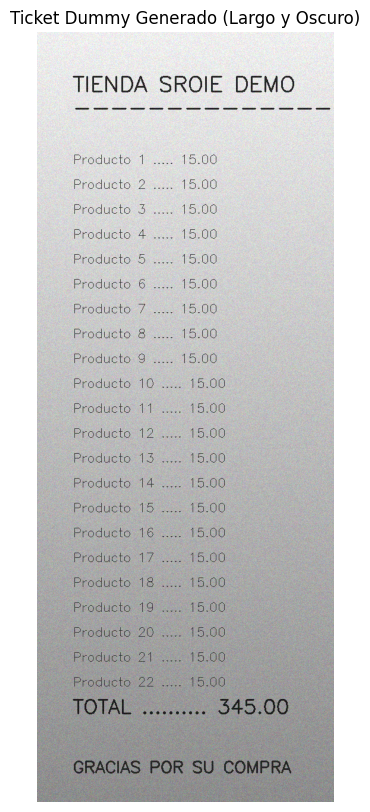

In [3]:
def create_dummy_receipt(width=500, height=1300):
    # Crear fondo gris claro con un fuerte degradado (sombras de iluminación)
    img = np.ones((height, width, 3), dtype=np.uint8) * 220
    for y in range(height):
        shadow = 1.0 - (y / height) * 0.45
        img[y, :, :] = (img[y, :, :] * shadow).astype(np.uint8)
        
    font = cv2.FONT_HERSHEY_SIMPLEX
    cv2.putText(img, "TIENDA SROIE DEMO", (60, 100), font, 1.2, (20,20,20), 2)
    cv2.putText(img, "--------------------", (60, 140), font, 1.2, (20,20,20), 2)
    
    # Rellenar productos para hacerlo largo (> 26cm)
    for i in range(1, 23):
        y_pos = 180 + i * 42
        cv2.putText(img, f"Producto {i} ..... 15.00", (60, y_pos), font, 0.7, (30,30,30), 1)
        
    cv2.putText(img, "TOTAL .......... 345.00", (60, 1150), font, 1.1, (10,10,10), 2)
    cv2.putText(img, "GRACIAS POR SU COMPRA", (60, 1250), font, 0.9, (20,20,20), 2)
    
    # Añadir un poco de ruido de imagen (sal y pimienta suave)
    noise = np.random.randint(0, 40, (height, width, 3), dtype=np.uint8)
    img = cv2.add(img, noise)
    return img

dummy_image = create_dummy_receipt()
plt.imshow(cv2.cvtColor(dummy_image, cv2.COLOR_BGR2RGB))
plt.title("Ticket Dummy Generado (Largo y Oscuro)")
plt.axis('off')
plt.show()

## 3. Pipeline de Preprocesamiento de Imágenes (OpenCV)
Lógica completa basada en el artículo, adaptada a la bifurcación para tickets >26cm.

In [4]:
def get_clean_background(img_gray):
    # Dilatar el texto negro (espaldir zonas blancas) para que el texto desaparezca
    kernel = np.ones((13, 13), np.uint8)
    dilated = cv2.dilate(img_gray, kernel, iterations=1)
    
    # Suavizar el fondo resultante
    bg = cv2.medianBlur(dilated, 25)
    return bg

def apply_preprocessing(img_gray):
    bg = get_clean_background(img_gray)
    
    # Resta de fondo: Absdiff evalúa diferencia, y lo invertimos.
    diff = 255 - cv2.absdiff(img_gray, bg)
    
    # Normalizamos (estiramiento de histograma al máximo contraste)
    # IMPORTANTE: Definir dtype=np.uint8 para evitar el error cv2.THRESH_OTSU (CV_64FC1)
    norm_diff = np.zeros(diff.shape, dtype=np.uint8)
    cv2.normalize(diff, norm_diff, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
    
    # Umbralización definitiva para dejar blanco/negro perfecto
    _, clean_thresh = cv2.threshold(norm_diff, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    
    return bg, diff, clean_thresh

def preprocess_and_bifurcate(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img.copy()
        
    h, w = gray.shape
    
    # Asumimos largo > 2.2 ratio (equivalente aprox a los tickets muy largos de rollo térmico > 26cm)
    ratio = h / w
    is_long = ratio > 2.2
    
    chunks = []
    if is_long:
        h_55 = int(h * 0.55)
        h_50 = int(h * 0.50)
        chunks.append(("Parte Superior (Top 55%)", gray[0:h_55, :]))
        chunks.append(("Parte Inferior (Bot 50%)", gray[h_50:h, :]))
    else:
        chunks.append(("Ticket Único", gray))
        
    results = []
    for label, chunk in chunks:
        bg, diff, thresh = apply_preprocessing(chunk)
        results.append({
            "label": label,
            "original_gray": chunk,
            "background": bg,
            "diff": diff,
            "final_clean": thresh
        })
    return results, is_long

## 4. Resultado del Proceso Visual

Ejecutando pipeline de preprocesamiento...
¿Se detectó ticket largo y se aplicó bifurcación?: SÍ



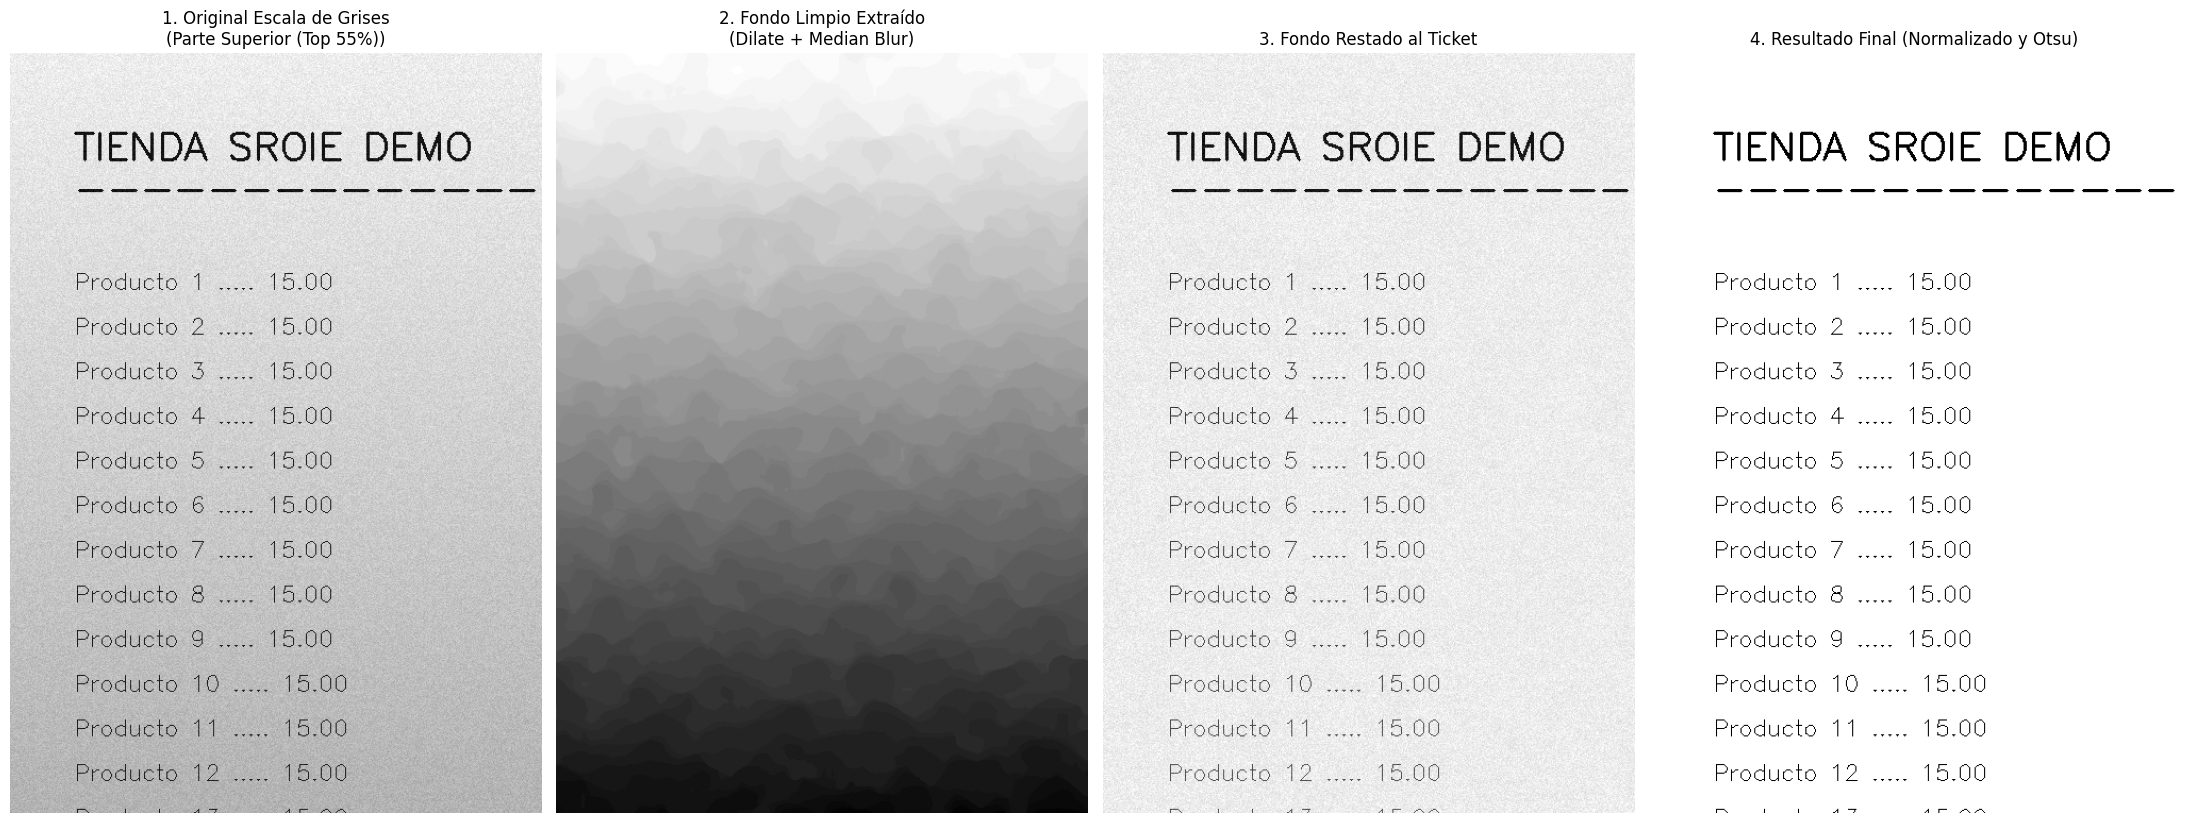

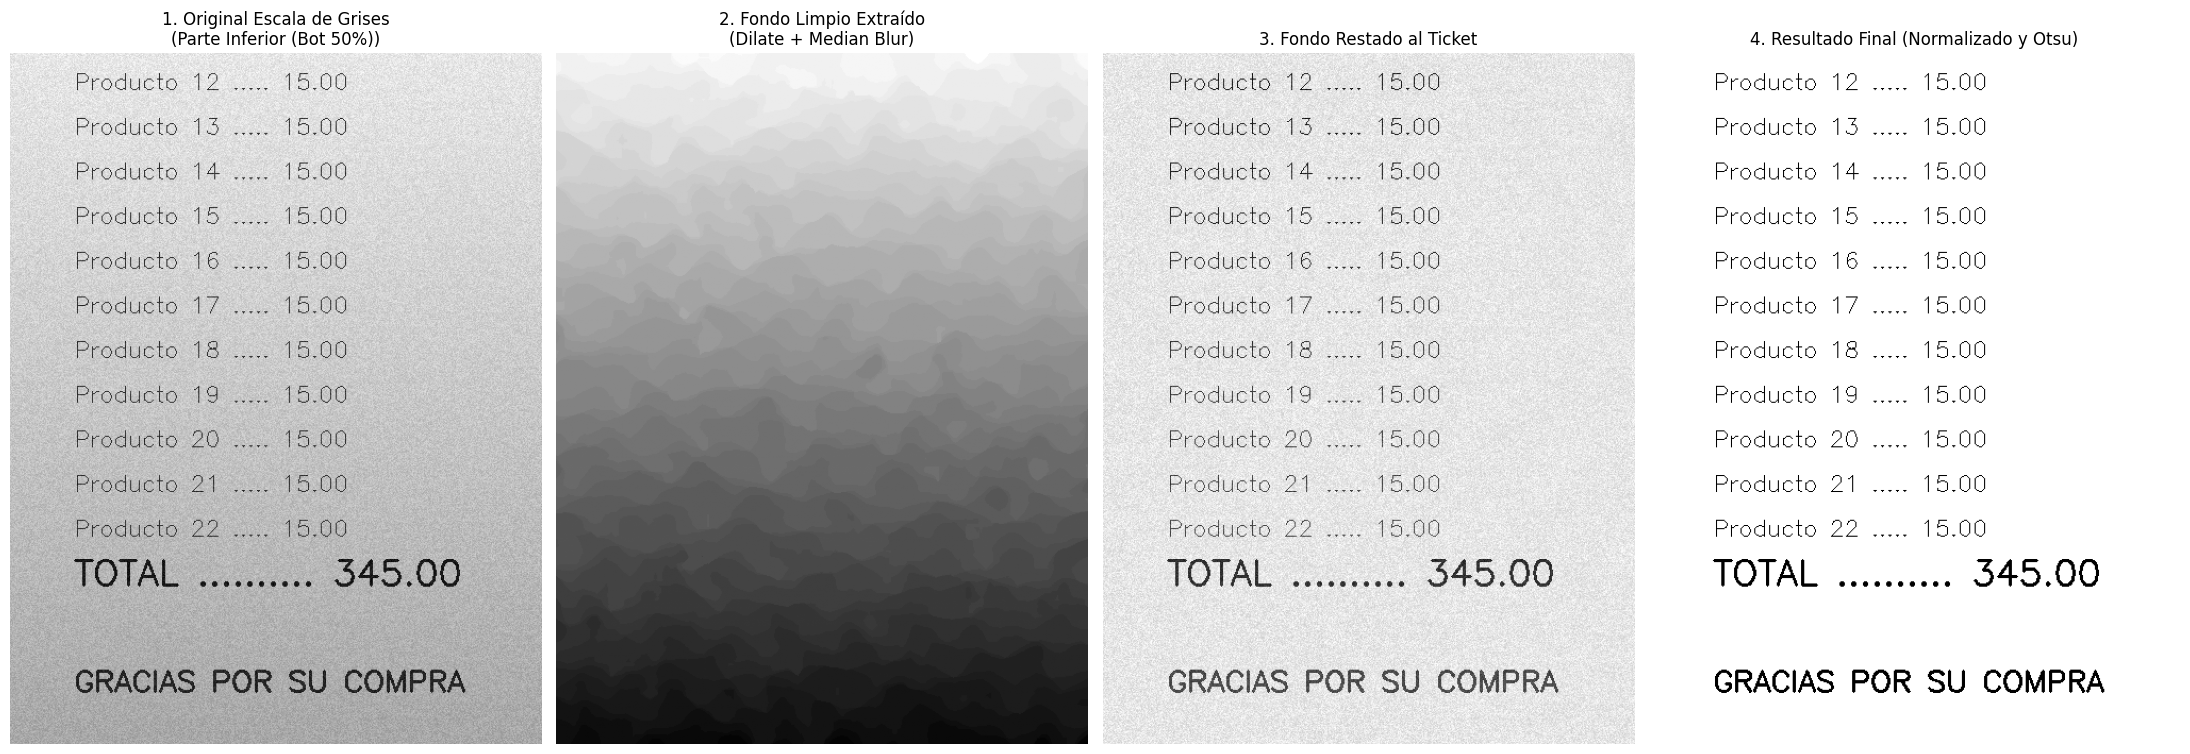

In [5]:
def plot_results(results):
    for res in results:
        fig, axes = plt.subplots(1, 4, figsize=(22, 10))
        
        axes[0].imshow(res['original_gray'], cmap='gray')
        axes[0].set_title(f"1. Original Escala de Grises\n({res['label']})")
        axes[0].axis('off')
        
        axes[1].imshow(res['background'], cmap='gray')
        axes[1].set_title(f"2. Fondo Limpio Extraído\n(Dilate + Median Blur)")
        axes[1].axis('off')
        
        axes[2].imshow(res['diff'], cmap='gray')
        axes[2].set_title(f"3. Fondo Restado al Ticket")
        axes[2].axis('off')
        
        axes[3].imshow(res['final_clean'], cmap='gray')
        axes[3].set_title(f"4. Resultado Final (Normalizado y Otsu)")
        axes[3].axis('off')
        
        plt.tight_layout()
        plt.show()

# Ejecutar con la imagen generada
print("Ejecutando pipeline de preprocesamiento...")
results, bifurcated = preprocess_and_bifurcate(dummy_image)
print(f"¿Se detectó ticket largo y se aplicó bifurcación?: {'SÍ' if bifurcated else 'NO'}\n")
plot_results(results)